In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. مدخلات المكمن الثابتة (Rock & Fluid Properties)
S_wir = 0.20      # الماء غير القابل للتحريك (20%)
S_or = 0.30       # النفط المتبقي الحبيس (30%)
k_rw_max = 0.60   # أقصى نفاذية للماء
n_o = 2.0         # معامل كوري للنفط
n_w = 3.0         # معامل كوري للماء

# 2. توليد نطاق تشبع الماء من S_wir إلى (1 - S_or)
Sw = np.linspace(S_wir, 1 - S_or, 100)

# 3. تطبيق معادلات Corey الرياضية
Sw_normalized = (Sw - S_wir) / (1 - S_wir - S_or)
krw = k_rw_max * (Sw_normalized) ** n_w
kro = (1 - Sw_normalized) ** n_o

print("✅ تم بناء النموذج الرياضي ومحاكاة النفاذية النسبية بنجاح!")

✅ تم بناء النموذج الرياضي ومحاكاة النفاذية النسبية بنجاح!


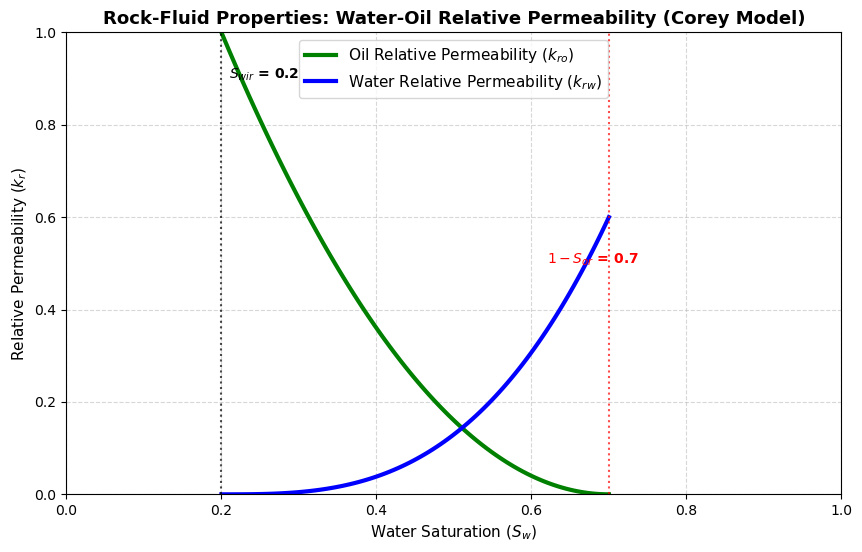

In [2]:
# 1. تجهيز لوحة الرسم بحجم مناسب
plt.figure(figsize=(10, 6))

# 2. رسم منحنيات النفاذية النسبية للنفط والماء
plt.plot(Sw, kro, label='Oil Relative Permeability ($k_{ro}$)', color='green', linewidth=3)
plt.plot(Sw, krw, label='Water Relative Permeability ($k_{rw}$)', color='blue', linewidth=3)

# 3. تحديد النقاط الحرجة هندسياً على الرسم
plt.axvline(x=S_wir, color='black', linestyle=':', alpha=0.7)
plt.text(S_wir + 0.01, 0.9, f'$S_{{wir}}$ = {S_wir}', fontsize=10, color='black', fontweight='bold')

plt.axvline(x=1 - S_or, color='red', linestyle=':', alpha=0.7)
plt.text(1 - S_or - 0.08, 0.5, f'$1 - S_{{or}}$ = {1 - S_or}', fontsize=10, color='red', fontweight='bold')

# 4. إضافة اللمسات الهندسية الاحترافية
plt.title('Rock-Fluid Properties: Water-Oil Relative Permeability (Corey Model)', fontsize=13, fontweight='bold')
plt.xlabel('Water Saturation ($S_w$)', fontsize=11)
plt.ylabel('Relative Permeability ($k_r$)', fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper center')

# 5. عرض اللوحة
plt.show()

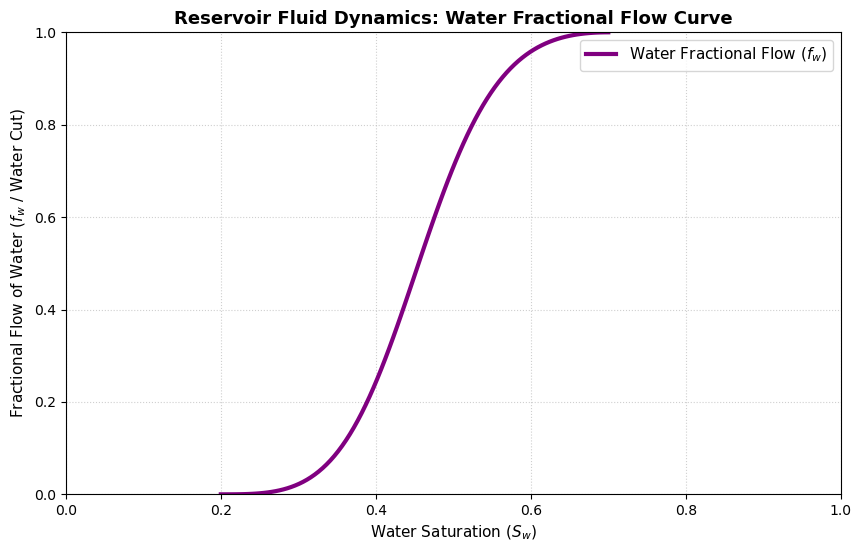

In [3]:
# 1. تحديد لزوجة النفط والماء (Viscosity)
mu_o = 3.0  # Oil viscosity in cP
mu_w = 1.0  # Water viscosity in cP

# 2. تطبيق معادلة التدفق الكسري (Fractional Flow Equation)
# أضفنا 1e-10 لتجنب القسمة على صفر عند أطراف المنحنى
fw = 1 / (1 + (kro / (krw + 1e-10)) * (mu_w / mu_o))

# 3. رسم منحنى التدفق الكسري
plt.figure(figsize=(10, 6))
plt.plot(Sw, fw, color='purple', linewidth=3, label='Water Fractional Flow ($f_w$)')

# 4. اللمسات الهندسية
plt.title('Reservoir Fluid Dynamics: Water Fractional Flow Curve', fontsize=13, fontweight='bold')
plt.xlabel('Water Saturation ($S_w$)', fontsize=11)
plt.ylabel('Fractional Flow of Water ($f_w$ / Water Cut)', fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()